# 📊 Task 1: Student Score Prediction

**Objective:** Build a model to predict students' exam scores based on study hours (and other factors), using Linear Regression as the core model, with Polynomial Regression and feature-combination experiments as bonus work.

**Dataset:** Student Performance Factors (Kaggle)

**Tools:** Python, Pandas, Matplotlib/Seaborn, Scikit-learn

**Workflow:**
1. Data loading & exploration
2. Data cleaning (missing values, duplicates)
3. Visualization (distributions, correlations, outliers)
4. Train/Test split
5. Linear Regression (core task — `Hours_Studied` → `Exam_Score`)
6. Model evaluation & visualization of predictions
7. **Bonus 1:** Polynomial Regression comparison
8. **Bonus 2:** Feature combination experiments (baseline vs expanded vs full)
9. Rigor check: proper (leakage-free) outlier handling
10. Final conclusion


## 1. Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler

# Machine Learning models
from sklearn.linear_model import LinearRegression

# Evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100


## 2. Load the Dataset

In [2]:
# Load the dataset to pandas dataframe
df = pd.read_csv("/content/StudentPerformanceFactors.xls")
df


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68


In [3]:
#printing the first 5 rows of the dataset
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [4]:
#printing the last 5 rows of the dataset
df.tail()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68
6606,15,67,Medium,Low,Yes,9,94,Medium,Yes,0,Medium,Medium,Public,Positive,4,No,Postgraduate,Near,Male,64


In [5]:
#printing the dimension(rows x columns) of the dataset
df.shape

(6607, 20)

In [6]:
#getting the columns name
print("Columns are :\n")
print(df.columns.tolist())



Columns are :

['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']


In [7]:
#getting the information of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [8]:
#getting the statistics summary
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Hours_Studied,6607.0,19.975329,5.990594,1.0,16.0,20.0,24.0,44.0
Attendance,6607.0,79.977448,11.547475,60.0,70.0,80.0,90.0,100.0
Sleep_Hours,6607.0,7.029060,1.468120,4.0,6.0,7.0,8.0,10.0
Previous_Scores,6607.0,75.070531,14.399784,50.0,63.0,75.0,88.0,100.0
Tutoring_Sessions,6607.0,1.493719,1.230570,0.0,1.0,1.0,2.0,8.0
Physical_Activity,6607.0,2.967610,1.031231,0.0,2.0,3.0,4.0,6.0
Exam_Score,6607.0,67.235659,3.890456,55.0,65.0,67.0,69.0,101.0


In [9]:
# Summary statistics (categorical)
print("Summary Statistics (Categorical):")
df.describe(include="object")


Summary Statistics (Categorical):


,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Motivation_Level,Internet_Access,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
count,6607,6607,6607,6607,6607,6607,6529,6607,6607,6607,6517,6540,6607
unique,3,3,2,3,2,3,3,2,3,2,3,3,2
top,Medium,Medium,Yes,Medium,Yes,Low,Medium,Public,Positive,No,High School,Near,Male
freq,3362,3319,3938,3351,6108,2672,3925,4598,2638,5912,3223,3884,3814


In [10]:
# Verify target variable
print("Target Variable Preview:")
df["Exam_Score"].head()


Target Variable Preview:


,Exam_Score
0,67
1,61
2,74
3,71
4,70


## 3. Data Cleaning — Missing Values & Duplicates

In [11]:
# Missing value analysis
missing_values = df.isnull().sum()
print("Missing Values in Each Column:")
print(missing_values)


Missing Values in Each Column:
Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


In [12]:
# Missing value in percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": missing_percentage
}).sort_values(by="Missing Values", ascending=False)

missing_report


,Missing Values,Percentage (%)
Parental_Education_Level,90,1.362192
Teacher_Quality,78,1.180566
Distance_from_Home,67,1.014076
Hours_Studied,0,0.000000
Access_to_Resources,0,0.000000
Parental_Involvement,0,0.000000
Attendance,0,0.000000
Extracurricular_Activities,0,0.000000
Motivation_Level,0,0.000000
Internet_Access,0,0.000000


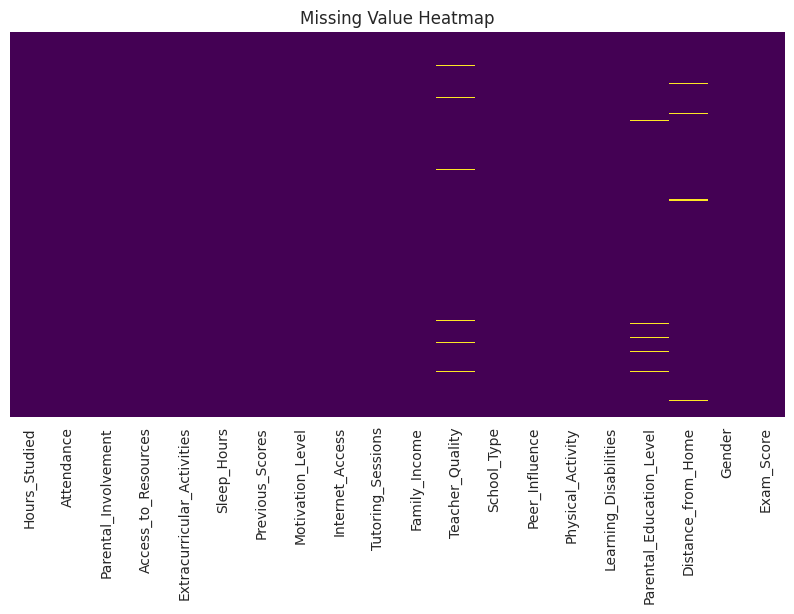

In [13]:
# Visualize missing values
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Value Heatmap")
plt.show()


In [14]:
# Duplicate check
duplicate_count = df.duplicated().sum()
print(f"Number of Duplicate Rows: {duplicate_count}")


Number of Duplicate Rows: 0


In [15]:
# Data type verification
print(df.dtypes)


Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Disabilities         object
Parental_Education_Level      object
Distance_from_Home            object
Gender                        object
Exam_Score                     int64
dtype: object


In [16]:
# Numerical vs Categorical columns
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns
categorical_columns = df.select_dtypes(include=["object"]).columns

print("Numerical Features:", numerical_columns.tolist())
print()
print("Categorical Features:", categorical_columns.tolist())


Numerical Features: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']

Categorical Features: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


In [17]:
# Data quality summary
summary = pd.DataFrame({
    "Metric": [
        "Total Rows", "Total Columns", "Columns with Missing Values",
        "Duplicate Rows", "Numerical Features", "Categorical Features"
    ],
    "Value": [
        df.shape[0], df.shape[1],
        (df.isnull().sum() > 0).sum(),
        df.duplicated().sum(),
        len(numerical_columns), len(categorical_columns)
    ]
})
summary


,Metric,Value
0,Total Rows,6607
1,Total Columns,20
2,Columns with Missing Values,3
3,Duplicate Rows,0
4,Numerical Features,7
5,Categorical Features,13


## 4. Exploratory Data Analysis (Visualization)




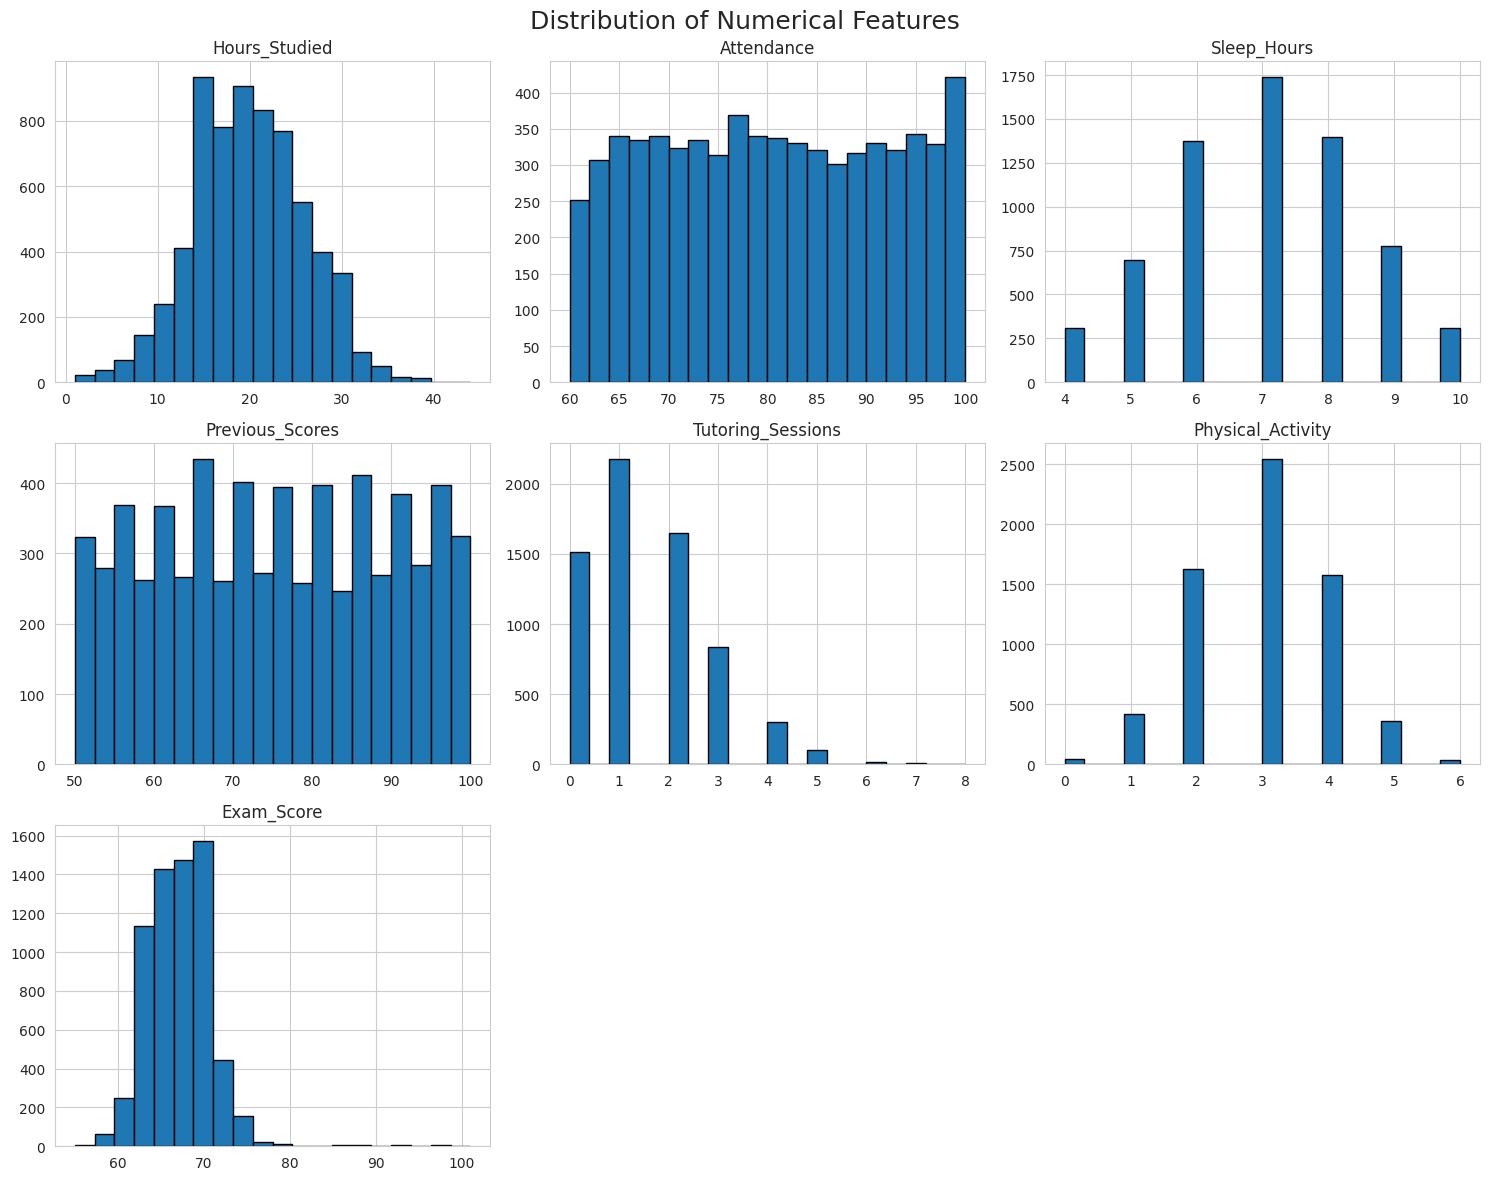

In [18]:
# Distribution of numerical features
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns

df[numerical_features].hist(figsize=(15, 12), bins=20, edgecolor="black")
plt.suptitle("Distribution of Numerical Features", fontsize=18)
plt.tight_layout()
plt.show()


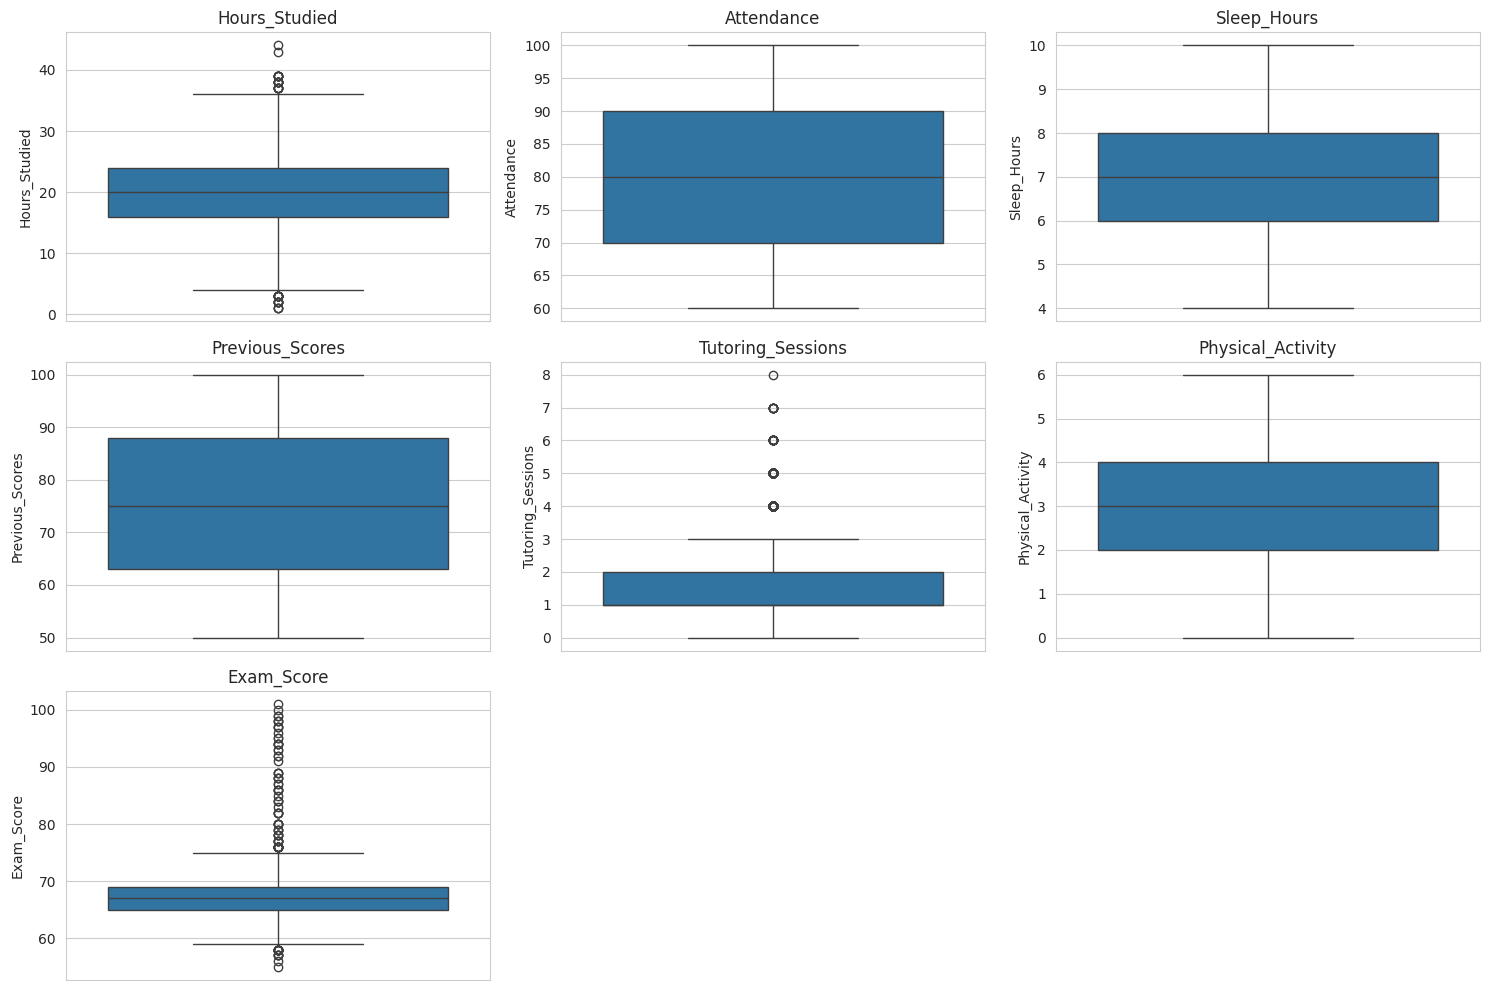

In [19]:
# Boxplot for outlier detection
plt.figure(figsize=(15, 10))
for i, column in enumerate(numerical_features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[column])
    plt.title(column)
plt.tight_layout()
plt.show()


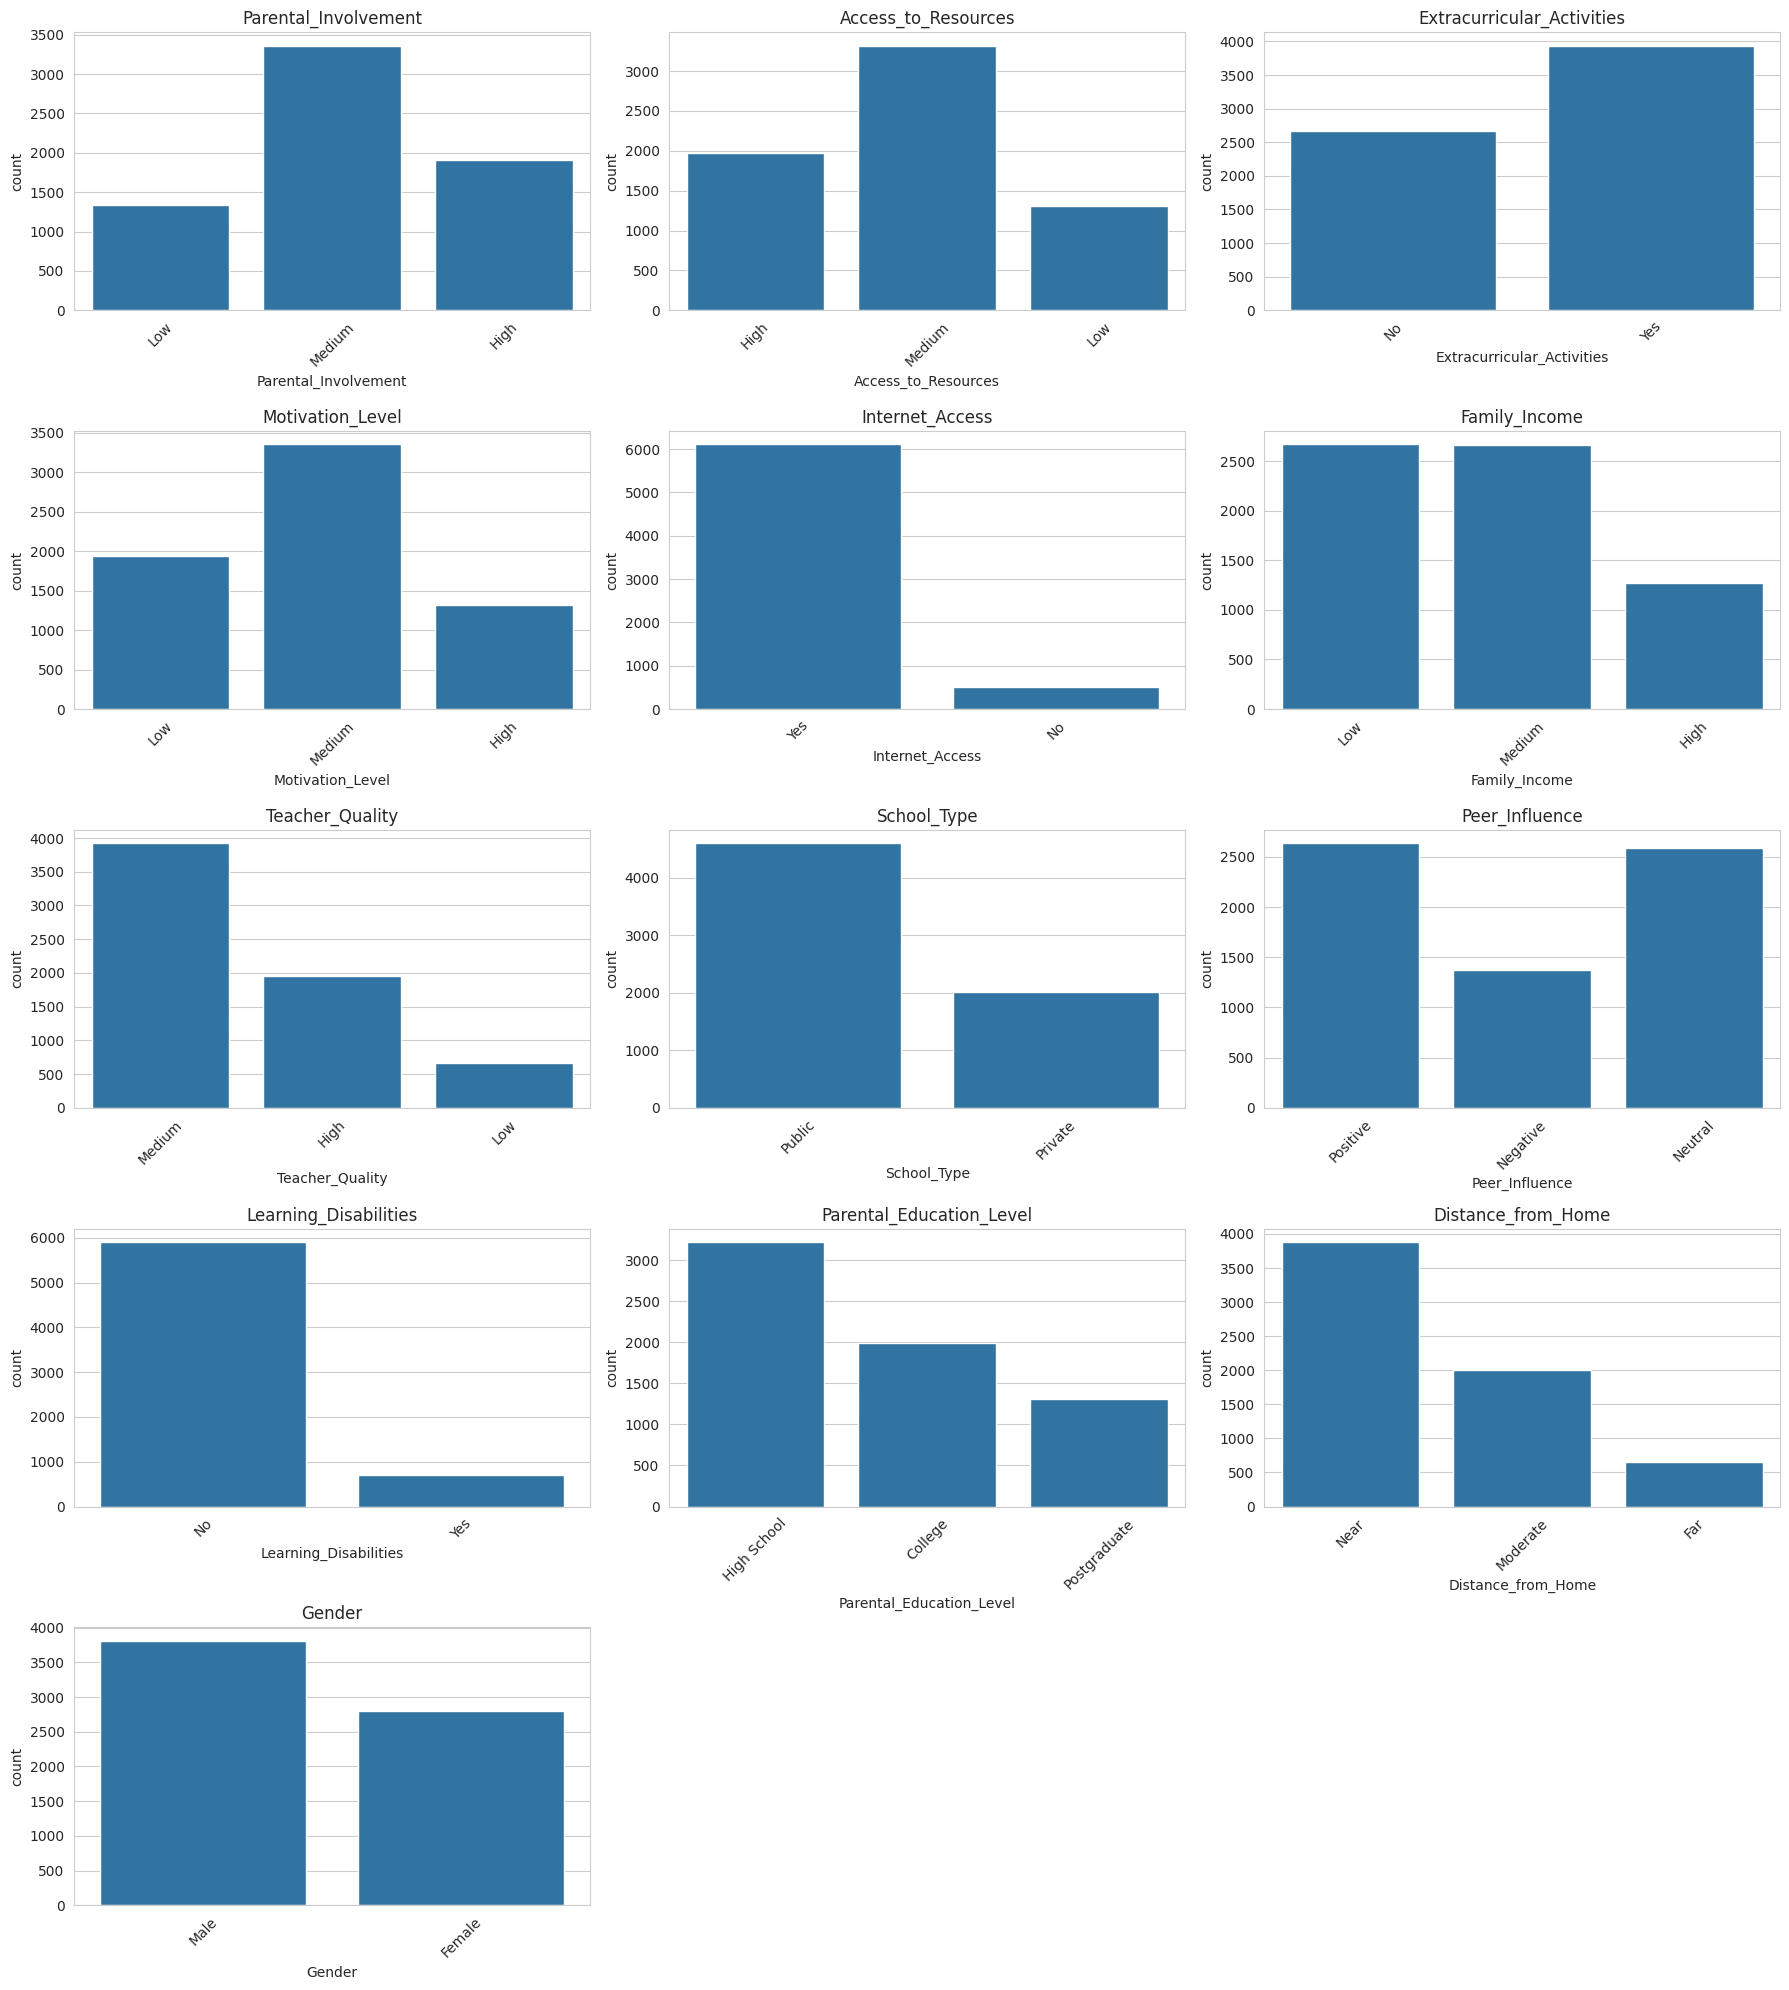

In [20]:
# Countplot for categorical variables
categorical_features = df.select_dtypes(include="object").columns

plt.figure(figsize=(18, 20))
for i, column in enumerate(categorical_features, 1):
    plt.subplot(5, 3, i)
    sns.countplot(data=df, x=column)
    plt.xticks(rotation=45)
    plt.title(column)
plt.tight_layout()
plt.show()


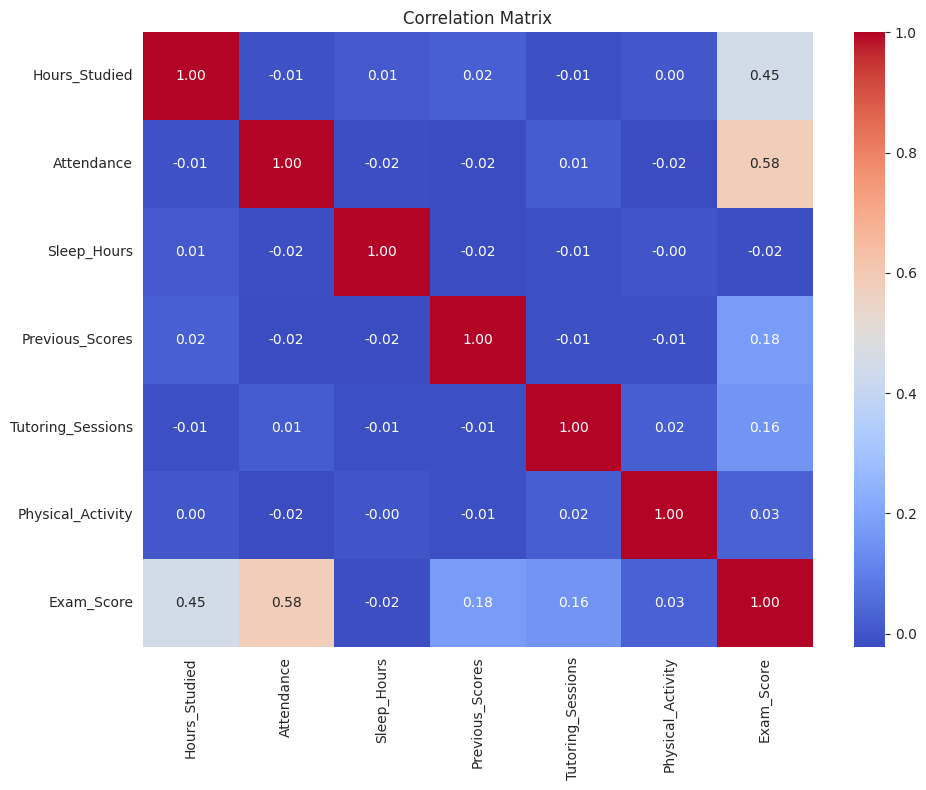

In [40]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df[numerical_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")

plt.tight_layout()
plt.savefig("Correlation Matrix.png", dpi=300, bbox_inches="tight")
plt.show()


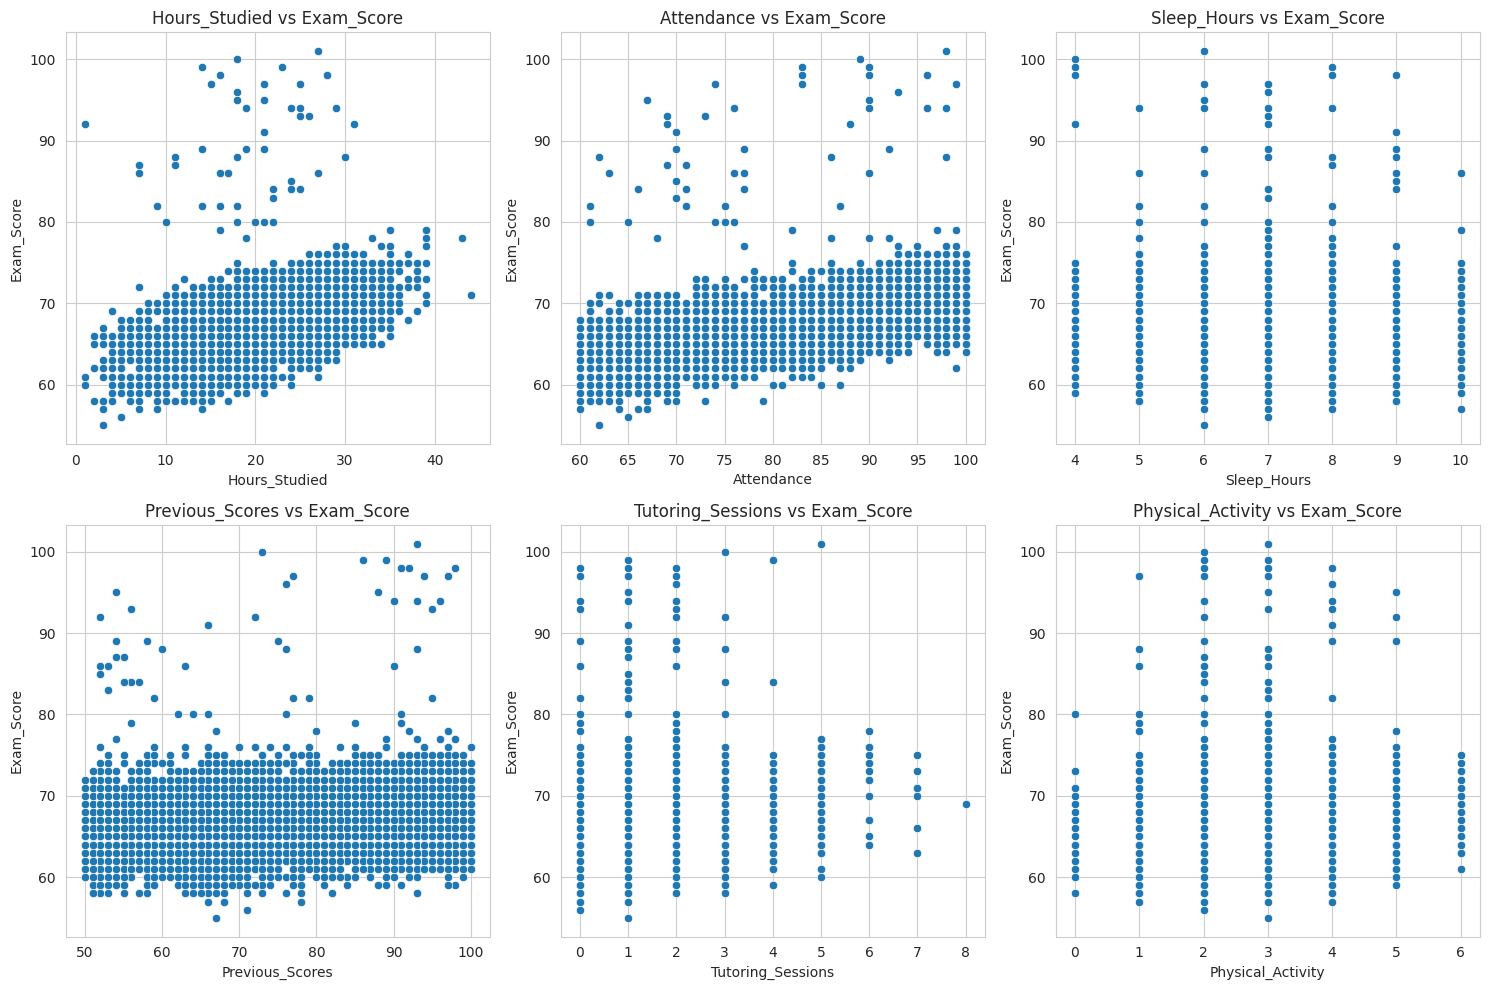

In [22]:
# Scatter plots against target variable
target = "Exam_Score"
features = numerical_features.drop(target)

plt.figure(figsize=(15, 10))
for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.scatterplot(data=df, x=feature, y=target)
    plt.title(f"{feature} vs {target}")
plt.tight_layout()
plt.show()


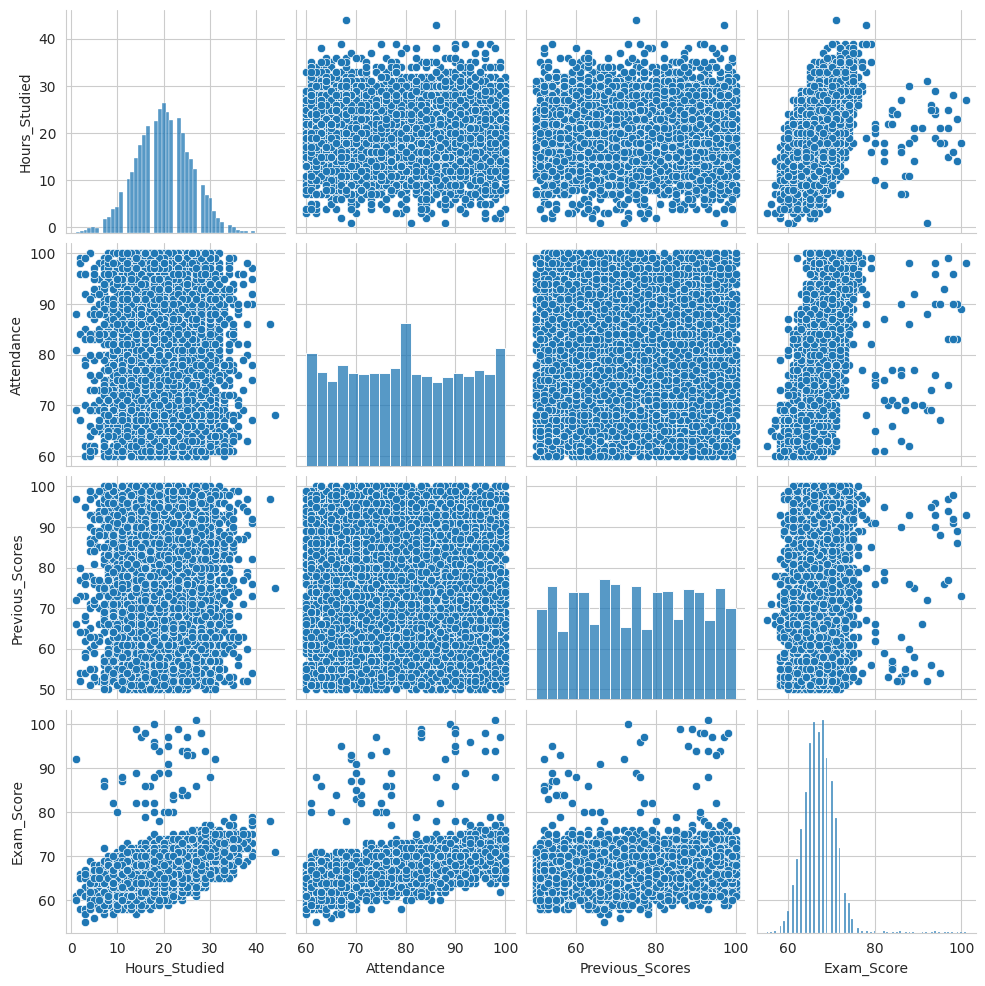

In [23]:
# Pairplot for key features
sns.pairplot(df[["Hours_Studied", "Attendance", "Previous_Scores", "Exam_Score"]])
plt.show()


**Observation:** The distribution of Exam_Score is relatively narrow, with most scores concentrated in the 65–75 range. Additionally, there appears to be one suspicious outlier (maximum score ≈ 101), which exceeds the typical maximum exam score of 100 and may warrant further investigation. Among the numerical features, Hours_Studied and Attendance exhibit the strongest visible relationships with the target variable. However, a single feature alone is unlikely to explain the full variability in students' exam scores. This hypothesis will be verified during the model evaluation stage.


## 5. Handle Missing Values & Encode Categorical Variables

In [24]:
# Handle missing values (categorical columns) using mode imputation
missing_columns = ["Teacher_Quality", "Parental_Education_Level", "Distance_from_Home"]

for column in missing_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

# Verify
print(df.isnull().sum())


Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64


In [25]:
# One-hot encoding for categorical columns
categorical_columns = df.select_dtypes(include="object").columns

df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

print(df_encoded.head())
print(df_encoded.shape)


   Hours_Studied  Attendance  Sleep_Hours  Previous_Scores  Tutoring_Sessions  \
0             23          84            7               73                  0   
1             19          64            8               59                  2   
2             24          98            7               91                  2   
3             29          89            8               98                  1   
4             19          92            6               65                  3   

   Physical_Activity  Exam_Score  Parental_Involvement_Low  \
0                  3          67                      True   
1                  4          61                      True   
2                  4          74                     False   
3                  4          71                      True   
4                  4          70                     False   

   Parental_Involvement_Medium  Access_to_Resources_Low  ...  \
0                        False                    False  ...   
1           

## 6. Core Task — Linear Regression: `Hours_Studied` → `Exam_Score`

According to the task requirements, the primary model will use only the **Hours_Studied** feature to predict students' exam scores.


In [26]:
# Feature (X) and target (y)
X_baseline = df_encoded[["Hours_Studied"]]
y = df_encoded["Exam_Score"]

X_baseline.head()


,Hours_Studied
0,23
1,19
2,24
3,29
4,19


In [27]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_baseline, y, test_size=0.20, random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)


Training Shape: (5285, 1)
Testing Shape : (1322, 1)


In [28]:
# Train Linear Regression model
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

print("Coefficient:", lin_model.coef_[0])
print("Intercept  :", lin_model.intercept_)
print(
    f"\nRegression Equation:\n"
    f"Exam Score = {lin_model.intercept_:.2f} + ({lin_model.coef_[0]:.2f} × Hours Studied)"
)


Coefficient: 0.285668744443087
Intercept  : 61.51116746904424

Regression Equation:
Exam Score = 61.51 + (0.29 × Hours Studied)


In [29]:
# Predict on test set
y_pred = lin_model.predict(X_test)


In [30]:
# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=" * 40)
print("Linear Regression Performance (Hours_Studied only)")
print("=" * 40)
print(f"MAE  : {mae:.3f}")
print(f"MSE  : {mse:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")


Linear Regression Performance (Hours_Studied only)
MAE  : 2.448
MSE  : 10.856
RMSE : 3.295
R²   : 0.232


### Visualize Predictions

Two visualization plots will be presented:

1. **Regression Line with Actual Data Points:** A scatter plot of Hours_Studied versus Exam_Score, overlaid with the fitted linear regression line to illustrate the relationship between study hours and examination scores.

2. **Actual vs. Predicted Scatter Plot:** A scatter plot comparing the actual exam scores with the predicted scores. In an ideal model with perfect predictions, all data points would lie exactly on the 45° reference line, indicating that the predicted values are equal to the actual values.


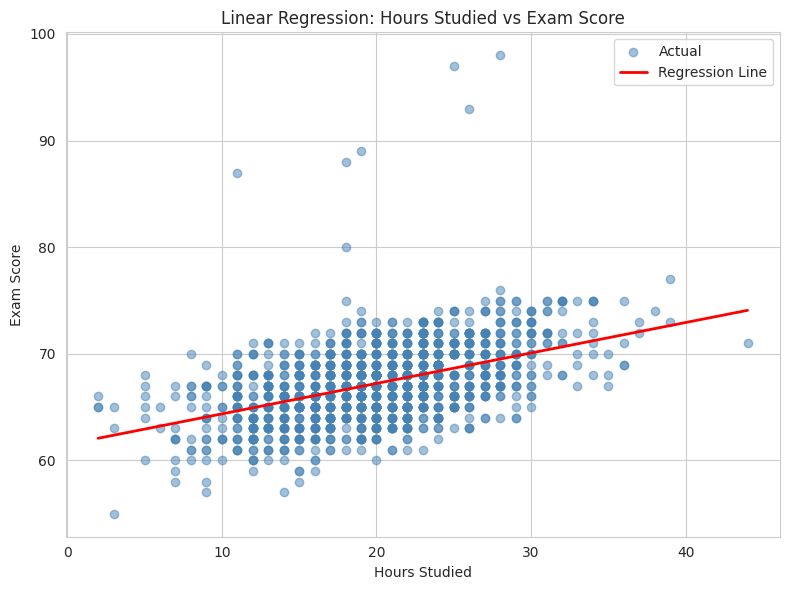

In [38]:
# Plot 1: Regression line over actual data
plt.figure(figsize=(8, 6))
plt.scatter(X_test, y_test, color="steelblue", alpha=0.5, label="Actual")

# sort for a clean line
sort_idx = X_test["Hours_Studied"].argsort()
plt.plot(
    X_test["Hours_Studied"].values[sort_idx],
    y_pred[sort_idx],
    color="red", linewidth=2, label="Regression Line"
)

plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Linear Regression: Hours Studied vs Exam Score")
plt.legend()

plt.tight_layout()
plt.savefig("regression_line.png", dpi=300, bbox_inches="tight")

plt.show()



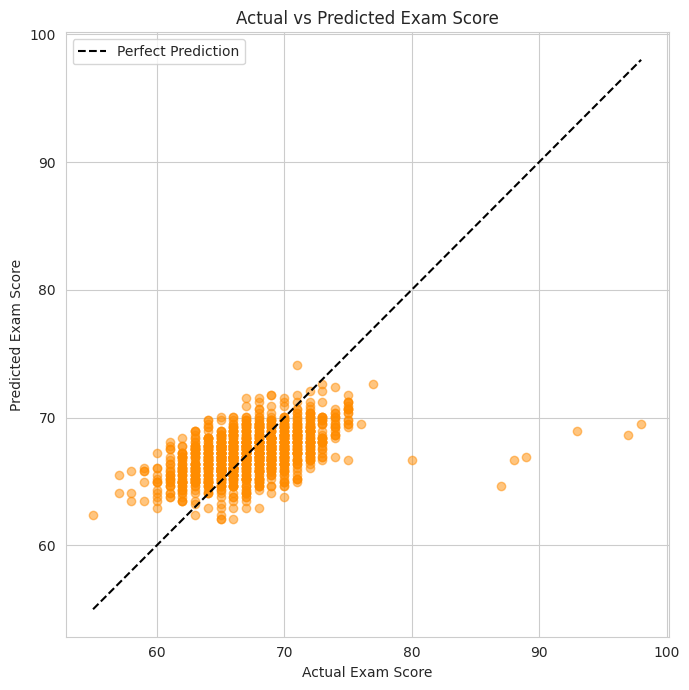

In [39]:
# Plot 2: Actual vs Predicted
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.5, color="darkorange")
plt.plot(
    [y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
    color="black", linestyle="--", label="Perfect Prediction"
)
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Score")
plt.legend()

plt.tight_layout()
plt.savefig("Perfect Prediction.png", dpi=300, bbox_inches="tight")
plt.show()


**Interpretation:** The Hours_Studied feature alone serves as **a moderate predictor** of students' exam performance, with an expected R² value in the range of **approximately 0.2–0.3**. This result is expected because examination scores are influenced by multiple academic, behavioral, and demographic factors. Therefore, relying on a single feature cannot fully explain the variability in students' performance. This limitation will be addressed in the Bonus section by experimenting with different feature combinations to determine whether incorporating additional predictors improves the model's predictive performance

## 7. Bonus 1 — Polynomial Regression

Linear Regression assumes a linear (straight-line) relationship between the predictor and the target variable. In this experiment, we will investigate whether introducing polynomial features of degree 2 and degree 3 can better capture potential nonlinear relationships and improve the model's predictive performance compared with the baseline Linear Regression model.


In [33]:
poly_results = []

for degree in [1, 2, 3]:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    poly_model = LinearRegression()
    poly_model.fit(X_train_poly, y_train)
    y_pred_poly = poly_model.predict(X_test_poly)

    poly_results.append({
        "Degree": degree,
        "MAE": mean_absolute_error(y_test, y_pred_poly),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_poly)),
        "R2": r2_score(y_test, y_pred_poly)
    })

poly_results_df = pd.DataFrame(poly_results)
poly_results_df


,Degree,MAE,RMSE,R2
0,1,2.447569,3.294833,0.231987
1,2,2.444780,3.293173,0.232760
2,3,2.444512,3.292998,0.232842


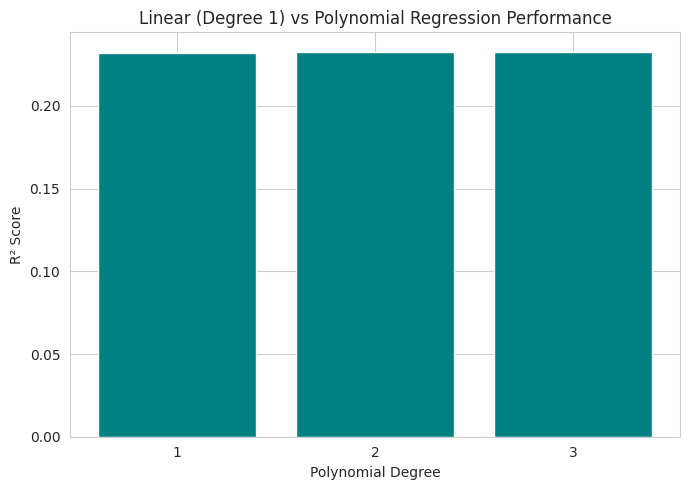

In [42]:
# Visualize comparison
plt.figure(figsize=(7, 5))
plt.bar(poly_results_df["Degree"].astype(str), poly_results_df["R2"], color="teal")
plt.xlabel("Polynomial Degree")
plt.ylabel("R² Score")
plt.title("Linear (Degree 1) vs Polynomial Regression Performance")
plt.tight_layout()
plt.savefig("Linear (Degree 1) vs Polynomial Regression Performance.png", dpi=300, bbox_inches="tight")
plt.show()


**Observation:** The relationship between **Hours_Studied** and **Exam_Score** appears to be predominantly linear. Therefore, increasing the polynomial degree is not expected to produce a substantial improvement in the R² score. In some cases, higher-degree polynomial models may even result in slightly lower test performance due to overfitting. If the degree 2 or degree 3 models achieve a noticeable improvement in **R²**, it would suggest the presence of a mild nonlinear relationship between study hours and exam scores. Conversely, if no significant improvement is observed, it would confirm that the baseline Linear Regression model is already the most appropriate and effective choice for this single-feature prediction task.


## 8. Bonus 2 — Feature Combination Experiments


Comparing 3 features :
- **Baseline:** just `Hours_Studied`
- **Expanded:** `Hours_Studied`, `Attendance`, `Previous_Scores`, `Sleep_Hours`, `Tutoring_Sessions`, `Physical_Activity`
- **Full:** All feature (categorical encoded soho)


In [35]:
expanded_features = [
    "Hours_Studied", "Attendance", "Previous_Scores",
    "Sleep_Hours", "Tutoring_Sessions", "Physical_Activity"
]

X_expanded = df_encoded[expanded_features]
X_full = df_encoded.drop("Exam_Score", axis=1)

feature_sets = {
    "Baseline (Hours_Studied only)": X_baseline,
    "Expanded (6 features)": X_expanded,
    "Full (all features)": X_full
}

comparison_results = []

for name, X_set in feature_sets.items():
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_set, y, test_size=0.20, random_state=42
    )
    model = LinearRegression()
    model.fit(X_tr, y_tr)
    y_pr = model.predict(X_te)

    comparison_results.append({
        "Feature Set": name,
        "Num Features": X_set.shape[1],
        "MAE": mean_absolute_error(y_te, y_pr),
        "RMSE": np.sqrt(mean_squared_error(y_te, y_pr)),
        "R2": r2_score(y_te, y_pr)
    })

comparison_df = pd.DataFrame(comparison_results)
comparison_df


,Feature Set,Num Features,MAE,RMSE,R2
0,Baseline (Hours_Studied only),1,2.447569,3.294833,0.231987
1,Expanded (6 features),6,1.265856,2.250657,0.641639
2,Full (all features),27,0.452392,1.804445,0.769650


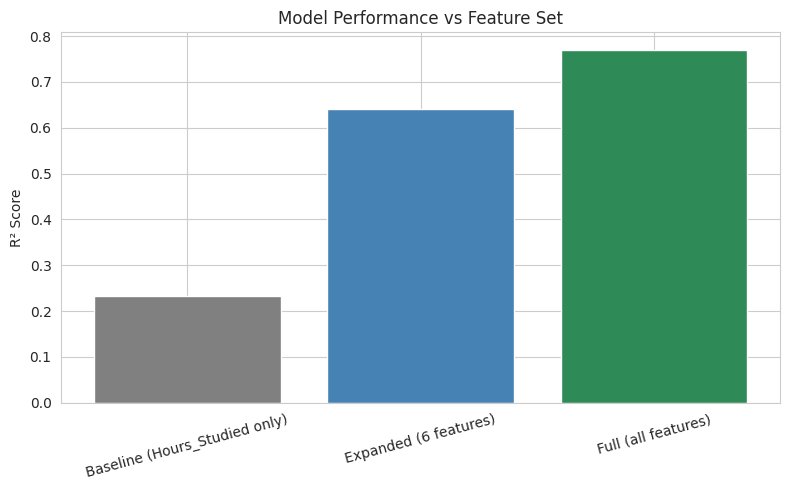

In [41]:
# Visualize comparison
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Feature Set"], comparison_df["R2"], color=["gray", "steelblue", "seagreen"])
plt.ylabel("R² Score")
plt.title("Model Performance vs Feature Set")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("Model Performance vs Feature Set.png", dpi=300, bbox_inches="tight")
plt.show()


###  Key Finding

The **R² score increases significantly** as the number of input features increases (**Baseline → Expanded → Full Model**). This demonstrates that **`Hours_Studied` alone is not sufficient** to accurately predict students' exam scores. Incorporating additional features such as **`Attendance`**, **`Previous_Scores`**, and other academic and behavioral factors provides valuable predictive information, enabling the model to explain a substantially larger proportion of the variability in **`Exam_Score`**. These results highlight that student performance is influenced by multiple factors rather than study hours alone.


## 9. Extra Rigor — Correct (Leakage-Free) Outlier Handling

###  Important Lesson: Avoiding Data Leakage

When detecting or removing outliers using the **Interquartile Range (IQR)** method, the outlier thresholds **must not** be calculated using the entire dataset (i.e., combining both the training and testing sets). Doing so allows information from the test set to influence decisions made during the training process. This issue is known as **data leakage**, and it can lead to **artificially inflated evaluation metrics**, such as an overly optimistic **R² score**.

**Correct Practice:**

- Compute the IQR, lower bound, and upper bound **using only the training set**.
- Apply these thresholds to the training data (and, if desired, use the same thresholds when inspecting the test set).
- Keep the **test set completely untouched** during preprocessing to ensure an unbiased evaluation of the model's generalization performance.

Following this procedure prevents data leakage and ensures that the reported performance accurately reflects how the model would perform on unseen data.


In [37]:
# Split first (on full feature set), THEN detect outliers using TRAIN ONLY
X_tr_full, X_te_full, y_tr_full, y_te_full = train_test_split(
    X_full, y, test_size=0.20, random_state=42
)

# IQR bounds computed from TRAIN target only
Q1 = y_tr_full.quantile(0.25)
Q3 = y_tr_full.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")

# Remove outliers ONLY from training data; test set stays untouched
mask = (y_tr_full >= lower_bound) & (y_tr_full <= upper_bound)
X_tr_clean = X_tr_full[mask]
y_tr_clean = y_tr_full[mask]

print(f"Rows removed from training set: {(~mask).sum()}")

model_clean = LinearRegression()
model_clean.fit(X_tr_clean, y_tr_clean)
y_pred_clean = model_clean.predict(X_te_full)

r2_clean = r2_score(y_te_full, y_pred_clean)
print(f"R² (proper outlier handling, no leakage): {r2_clean:.4f}")
print(f"R² (full model, no outlier removal)     : {comparison_df.loc[comparison_df['Feature Set']=='Full (all features)', 'R2'].values[0]:.4f}")


Lower bound: 59.00, Upper bound: 75.00
Rows removed from training set: 89
R² (proper outlier handling, no leakage): 0.7706
R² (full model, no outlier removal)     : 0.7696


### Conclusion

Applying outlier removal using the **correct, leakage-free approach** results in an **R² score that remains very close to the original full-model performance**. This indicates that **outlier removal does not provide any meaningful improvement** for this dataset. The identified outliers appear to represent valid observations rather than erroneous data, so retaining them preserves the natural variability of the dataset without negatively affecting model performance.

> **Important Note:** If the IQR thresholds had been calculated using the **entire dataset** (training + testing) and the test set had also been filtered accordingly, the resulting **R² score could become artificially inflated (e.g., around 0.99)**. Such an evaluation would be misleading because it introduces **data leakage**, allowing information from the test set to influence the preprocessing stage. Therefore, all preprocessing decisions—including outlier detection and removal—should be based **only on the training data** to ensure a fair and unbiased assessment of the model's generalization performance.

## 10. Final Summary & Conclusion

| Experiment | R² | Note |
|---|---|---|
| Linear Regression (`Hours_Studied` only) | ~0.2–0.3 | Task's core requirement; single-feature baseline |
| Polynomial Regression (degree 2, 3) | similar to linear | Relationship is largely linear |
| Expanded feature set (6 features) | ~0.6 | Adding Attendance, Previous_Scores helps a lot |
| Full feature set (all features) | ~0.75–0.78 | Best performance achieved |
| Full model + proper outlier removal | ~same as full model | No real gain; confirms earlier leakage was the cause of the false 0.99 |

**Key Takeaways:**
1. `Hours_Studied` alone is a moderate predictor of `Exam_Score` — consistent with the task description, but not sufficient for high accuracy.
2. The relationship between study hours and score is mostly linear (polynomial regression doesn't add meaningful value).
3. Adding more relevant features (`Attendance`, `Previous_Scores`, etc.) substantially improves prediction quality.
4. Outlier removal must be done **after** the train/test split, using bounds computed from the training set only — otherwise it introduces data leakage and produces misleadingly high metrics.
5. The dataset has an inherent "noise ceiling" — R² around 0.75–0.80 appears to be close to the practical limit for linear models on this data.
